# 💎📈 Predicting Diamond Prices using Hypothesis testing

**Background:** You're a data analyst working at an online jewelry retailer. You have to help the retailer understand and predict the distribution of diamonds they can expect to need prices for. 

**Task:** Pricing new diamonds acquired by the company. 

**Dataset:** Past sales.

Diamonds are evaluated based on a set of core characteristics known as the four C's:
* Cut
* Color
* Clarity
* Carat.

***Cut** refers to the quality of a diamond's form. Well-cut diamonds are symmetrical and reflect light well, giving them a sparkly appearance. 
**Color** is the color of the stone. The clearer the diamond, the higher its color grade. Yellower diamonds are less valuable.
**Clarity** refers to the number of imperfections on the surface of the stone or within it. Clearer diamonds are more valuable.
**Carat** is a measure of weight used for gems. A one-carat round-cut diamond is about the size of a green pea.*


### 📊 Task-1: 
Your first task is to **estimate the mean price of diamonds** sold by your client, the retailer.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [3]:
df = pd.read_csv("diamonds.csv")   # our sample

In [4]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


*Each **observation** is a **diamond**, and each **column** is a **feature** of that diamond.*

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53941 entries, 0 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53941 non-null  float64
 1   cut      53941 non-null  object 
 2   color    53941 non-null  object 
 3   clarity  53941 non-null  object 
 4   depth    53941 non-null  float64
 5   table    53941 non-null  float64
 6   price    53941 non-null  int64  
 7   x        53941 non-null  float64
 8   y        53941 non-null  float64
 9   z        53941 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,53941.000000,53941.000000,53941.000000,53941.000000,53941.000000,53941.000000,53941.000000
mean,0.797953,61.749447,57.457231,3932.885875,5.731183,5.734554,3.538753
std,0.474016,1.432641,2.234497,3989.452937,1.121767,1.142143,0.705707
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5325.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


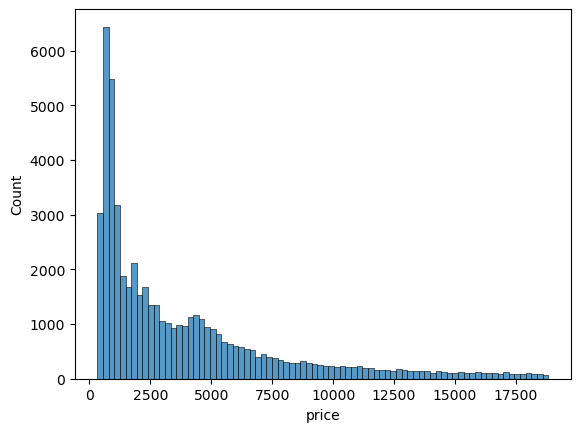

In [18]:
sns.histplot(df, x="price")
plt.show()

The visualization of the distribution of price is quite skewed. That makes sense. **More expensive diamonds should be rarer.**

Even though this distribution is skewed, the **sampling distribution of the mean** is expected to be **normal**, so a confidence interval is still appropriate here.

In [7]:
# mean of price
mean_price = df["price"].mean()
mean_price

np.float64(3932.8858753082072)

In [19]:
# Evaluating 95% confidence interval for mean to present this to our stakeholders

conf = 0.95

# sample size
n = df["price"].count()

# standard deviation of price
std_price = df["price"].std()

# standard error of the mean (SEM)
SEM = std_price / np.sqrt(n)

# calculate the 95% confidence interval for the mean price
interval = stats.norm.interval(confidence=conf, loc=mean_price, scale=SEM)

In [20]:
interval

(np.float64(3899.219067451682), np.float64(3966.5526831647326))

In [25]:
print("With 95% confidence, the true mean diamond price is between", interval[0], "and", interval[1])

With 95% confidence, the true mean diamond price is between 3899.219067451682 and 3966.5526831647326


*So with this result, you can be pretty confident that the true mean diamond price is somewhere close to $3,900*

### 📊 Task-2: 
Test whether diamonds with a **Premium cut** have a **average price above $4,500.**

<img src="task-2.png" width="700">

In [35]:
# finding the population mean for premium cut diamonds
df.groupby("cut")["price"].mean()

cut
Fair         4358.757764
Good         3929.812309
Ideal        3457.541970
Premium      4584.257704
Very Good    3981.759891
Name: price, dtype: float64

* You use the `stats.ttest_1samp` function to conduct a **one-sample ttest.**

* The first argument is the sample of your data, just one column, in this case the diamond prices for premium cut diamonds.

* Then you provide the mean under the null hypothesis as the argument pop mean. In this case, you use the value 4500.

* This function returns a sequence of three values, with the second being the p-value. You can then use this p-value to determine whether you're able to reject or fail to reject the null hypothesis.

In [55]:
# define significance level
alpha = 0.05

# sample of data to evaluate for t-test
premium = df[df["cut"]=="Premium"]["price"]

# population mean under null hypothesis
mean_null_hypo = 4500

# one-sample t-test
test_results = stats.ttest_1samp(premium, popmean=mean_null_hypo, alternative="greater")   # "greater" for right-tailed test
test_results

TtestResult(statistic=np.float64(2.275084997124123), pvalue=np.float64(0.011458055458398156), df=np.int64(13790))

*This function returns a sequence of three values, with the second being the p-value.*

In [51]:
if test_results[1]>0.05:
    print("Failed to reject the null with the p-value:", test_results[1])
else:
    print("Rejected the null with p-value:", test_results[1])

Rejected the null with p-value: 0.011458055458398156


## 📊 Task-3
Test whether **Good** and **Very good** cut diamonds **should be priced differently.**

<img src="task-3.png" width="700">

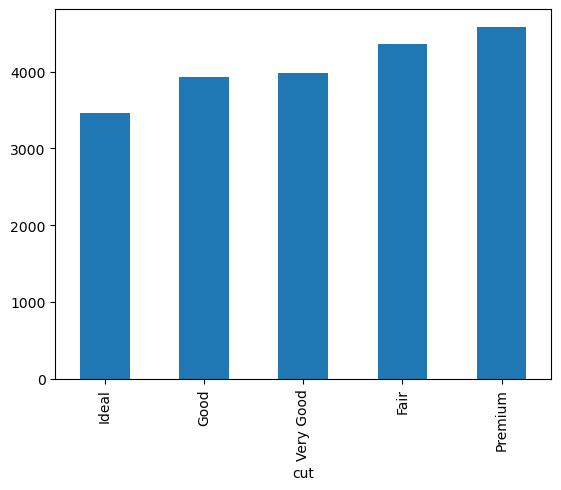

In [67]:
df.groupby("cut")["price"].mean().sort_values().plot(kind="bar")
plt.show()

*Looking at the values for average price, good and very good diamonds appear to have quite similar prices.*

* You can use a **two-sample t-test** to determine if that **similarity is statistically significant.**
* To further set your expectations, you can look at **boxplots** of the distribution of price based on the cut.

<Axes: xlabel='cut', ylabel='price'>

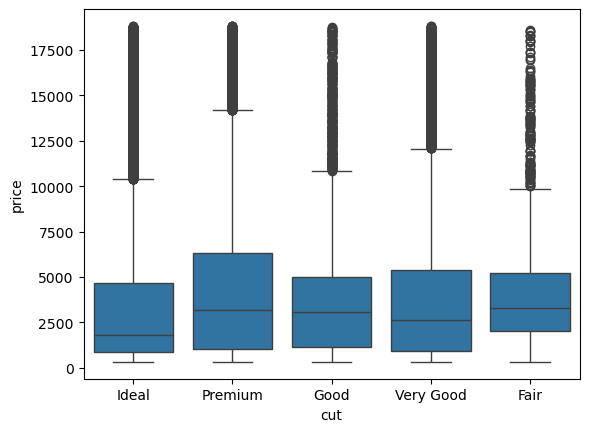

In [68]:
sns.boxplot(df, x="cut", y="price")

* By default, the categories in cut are not going to be visualized in the proper order.
* We have to include the **order** named argument.

* For palette, you could use a **sequential color map** because the cut categories are in **order of quality.**

/var/folders/6h/h489k5ln6r93tz_q7ssx2hj00000gn/T/ipykernel_13164/1515634032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="price", y="cut", order=cut_order, palette="Blues_r")


<Axes: xlabel='price', ylabel='cut'>

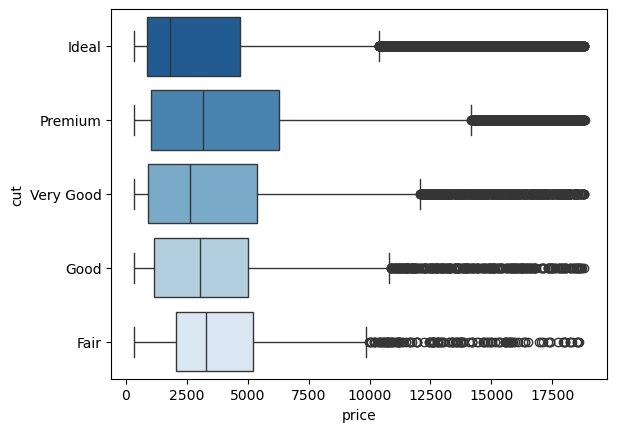

In [71]:
cut_order=["Ideal", "Premium", "Very Good", "Good", "Fair"]
sns.boxplot(df, x="price", y="cut", order=cut_order, palette="Blues_r")

* Notice that the median values for good and very good are different, and very good diamonds have a larger interquartile range, indicating potentially higher variability.
* But overall, it's not clear whether the mean price is significantly different between these two categories.

* So let's test this difference: 
   
    * You can use `stats.ttest_ind` with `ind` standing for **independent** - to conduct a **two-sample t-test** with **independent samples.**
   
    * You're assuming that these diamonds are from **two completely independent distributions.** That's a valid assumption here. ​here's no relationship between a diamond in the very good subset and a diamond in the good subset.
   
    * This function takes two arguments, both series of data, one from your first sample and one from your second sample. It returns the same type of result as the t-test one-sample function, t-testResults.
   
    * You don't use a `popmean` argument like you do in a one-sample t-test, because the goal here isn't to compare the sample mean against a particular value. Instead, you're comparing the means of two different groups directly against each other.

In [74]:
goods = df[df["cut"]=="Good"]["price"]
very_goods = df[df["cut"]=="Very Good"]["price"]

test_results = stats.ttest_ind(very_goods, goods)
test_results

TtestResult(statistic=np.float64(0.7941427626594914), pvalue=np.float64(0.4271234189400054), df=np.float64(16987.0))

In [75]:
if test_results[1]>0.05:
    print("Failed to reject the null with the p-value:", test_results[1])
else:
    print("Rejected the null with p-value:", test_results[1])

Failed to reject the null with the p-value: 0.4271234189400054
